## Football Match Outcome Prediction Using Machine Learning

This Jupyter Notebook presents an analysis of English Premier League match data and applies machine learning algorithms to predict match outcomes — **home win**, **draw**, or **away win**.

The dataset contains detailed statistics from Premier League matches between **2000 and 2025**, including scores, shots, cards, and other performance indicators.  
The goal of this project is to explore data patterns and develop a predictive model capable of forecasting match results.

---

### Dataset Overview

Each record in the dataset includes the following attributes:

- **Season** – season in which the match was played (e.g., 2020–2021)  
- **MatchDate** – date of the match  
- **HomeTeam** – name of the home team  
- **AwayTeam** – name of the away team  
- **FullTimeHomeGoals** – number of goals scored by the home team (full time)  
- **FullTimeAwayGoals** – number of goals scored by the away team (full time)  
- **FullTimeResult** – final match result (`H` = home win, `A` = away win, `D` = draw)  
- **HalfTimeHomeGoals** – goals scored by the home team at half time  
- **HalfTimeAwayGoals** – goals scored by the away team at half time  
- **HalfTimeResult** – result at half time (`H`, `A`, `D`)  
- **HomeShots** – total shots by the home team  
- **AwayShots** – total shots by the away team  
- **HomeShotsOnTarget** – shots on target by the home team  
- **AwayShotsOnTarget** – shots on target by the away team  
- **HomeCorners** – number of corners by the home team  
- **AwayCorners** – number of corners by the away team  
- **HomeFouls** – number of fouls committed by the home team  
- **AwayFouls** – number of fouls committed by the away team  
- **HomeYellowCards** – number of yellow cards for the home team  
- **AwayYellowCards** – number of yellow cards for the away team  
- **HomeRedCards** – number of red cards for the home team  
- **AwayRedCards** – number of red cards for the away team  

---

### Goal

To build a reliable predictive model for football match outcomes and identify the most influential features that affect match results.



## Importing Libraries

The following libraries will be used:  
- **pandas** and **numpy** for data manipulation  
- **matplotlib** and **seaborn** for visualization

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

##  Loading Data


In [8]:
data_path = "../data/epl_final.csv"
data = pd.read_csv(data_path)

In [9]:
data.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9380 entries, 0 to 9379
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Season             9380 non-null   object
 1   MatchDate          9380 non-null   object
 2   HomeTeam           9380 non-null   object
 3   AwayTeam           9380 non-null   object
 4   FullTimeHomeGoals  9380 non-null   int64 
 5   FullTimeAwayGoals  9380 non-null   int64 
 6   FullTimeResult     9380 non-null   object
 7   HalfTimeHomeGoals  9380 non-null   int64 
 8   HalfTimeAwayGoals  9380 non-null   int64 
 9   HalfTimeResult     9380 non-null   object
 10  HomeShots          9380 non-null   int64 
 11  AwayShots          9380 non-null   int64 
 12  HomeShotsOnTarget  9380 non-null   int64 
 13  AwayShotsOnTarget  9380 non-null   int64 
 14  HomeCorners        9380 non-null   int64 
 15  AwayCorners        9380 non-null   int64 
 16  HomeFouls          9380 non-null   int64 


In [5]:
data.describe()

,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000
mean,1.535394,1.182623,0.688273,0.518763,13.617484,10.810661,5.973134,4.693710,6.040299,4.774733,11.276333,11.765672,1.468124,1.792431,0.062473,0.085288
std,1.305432,1.157414,0.835079,0.735357,5.356424,4.696501,3.267954,2.750045,3.110619,2.749541,3.750250,3.924179,1.217190,1.288481,0.253221,0.290183
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,4.000000,3.000000,9.000000,9.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,13.000000,10.000000,6.000000,4.000000,6.000000,4.000000,11.000000,12.000000,1.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,14.000000,8.000000,6.000000,8.000000,6.000000,14.000000,14.000000,2.000000,3.000000,0.000000,0.000000
max,9.000000,9.000000,5.000000,5.000000,43.000000,37.000000,24.000000,20.000000,20.000000,19.000000,33.000000,29.000000,7.000000,9.000000,3.000000,2.000000


##  Data Preprocessing


In this section, the data is prepared for further analysis and modeling. Since machine learning models cannot work directly with text data, certain columns need to be converted into appropriate numerical or datetime formats.

For example, the date column is converted to a datetime format to extract useful features such as year, month, and day. Categorical variables, such as team names and match results, are encoded into numerical values to make them suitable for machine learning models.



We import **LabelEncoder** from `sklearn.preprocessing`, which will be used to convert categorical values into numerical form.


In [6]:
from sklearn.preprocessing import LabelEncoder

Date Processing: converting dates and extracting year, month, day, and day of the week


In [7]:
data["MatchDate"] = pd.to_datetime(data["MatchDate"], format='%Y-%m-%d')

data['Year'] = data['MatchDate'].dt.year
data['Month'] = data['MatchDate'].dt.month
data['Day'] = data['MatchDate'].dt.day
data['Weekday'] = data['MatchDate'].dt.dayofweek


From the 'Season' column, we extract the starting year and convert it to an integer (int)


In [8]:
data["SeasonStart"] = data["Season"].str[:4].astype(int)

Encoding match results: H (home win), D (draw), A (away win)

We map them to numbers for easier use in machine learning models.


In [9]:
result_mapping = {"H": 1, "D": 0, "A": 2}
data["FullTimeResult"] = data["FullTimeResult"].map(result_mapping)
data["HalfTimeResult"] = data["HalfTimeResult"].map(result_mapping)

Creating a unique list of all teams and converting them into numbers using LabelEncoder, so that the model can work with categorical data.



In [10]:
all_teams = pd.concat([data["HomeTeam"], data["AwayTeam"]]).unique()
le_teams = LabelEncoder()
le_teams.fit(all_teams)
data["HomeTeam"] = le_teams.transform(data["HomeTeam"])
data["AwayTeam"] = le_teams.transform(data["AwayTeam"])


Mapping the encoded team values back to their original names for easier display and interpretation.


In [11]:
data["HomeTeamName"] = le_teams.inverse_transform(data["HomeTeam"])
data["AwayTeamName"] = le_teams.inverse_transform(data["AwayTeam"])


Moving the team name columns right after the encoded HomeTeam and AwayTeam columns.

First, they are removed if they already exist, and then inserted in the appropriate positions.



In [12]:
cols = list(data.columns)

if "HomeTeamName" in cols:
    cols.remove("HomeTeamName")
if "AwayTeamName" in cols:
    cols.remove("AwayTeamName")
    
home_idx = cols.index("HomeTeam") + 1
away_idx = cols.index("AwayTeam") + 1

cols.insert(home_idx, "HomeTeamName")
cols.insert(away_idx + 1, "AwayTeamName")

data = data[cols]


In [13]:
data.head()

,Season,MatchDate,HomeTeam,HomeTeamName,AwayTeam,AwayTeamName,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,...,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,Year,Month,Day,Weekday,SeasonStart
0,2000/01,2000-08-19,12,Charlton,26,Man City,4,0,1,2,...,12,1,2,0,0,2000,8,19,5,2000
1,2000/01,2000-08-19,13,Chelsea,43,West Ham,4,2,1,1,...,14,1,2,0,0,2000,8,19,5,2000
2,2000/01,2000-08-19,14,Coventry,28,Middlesbrough,1,3,2,1,...,21,5,3,1,0,2000,8,19,5,2000
3,2000/01,2000-08-19,16,Derby,36,Southampton,2,2,0,1,...,13,1,1,0,0,2000,8,19,5,2000
4,2000/01,2000-08-19,22,Leeds,17,Everton,2,0,1,2,...,20,1,3,0,0,2000,8,19,5,2000


## Exploratory Data Analysis (EDA)

This section focuses on identifying key patterns and characteristics in the data, including result distributions, seasonal and temporal variations, and basic team statistics.

New features that may be relevant for predicting match outcomes are also created. The analysis is supported with visualizations to better understand the data structure and relationships between variables.



**Match Outcome Distribution Analysis**

In this part of the analysis, we show the distribution of final match results. Outcomes are categorized as:

- **Home Win** (encoded as 1)  
- **Draw** (encoded as 0)  
- **Away Win** (encoded as 2)  

The chart will display how many times each outcome occurred in the dataset.


In [14]:
print(data["FullTimeResult"].unique())


[1 2 0]


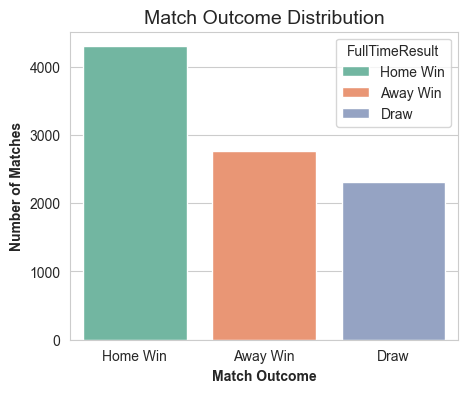

In [17]:
sns.set_style("whitegrid")

palette = sns.color_palette("Set2")[:3]

plt.figure(figsize=(5, 4))

result_labels = {
    1: "Home Win",
    0: "Draw",
    2: "Away Win"
}

sns.countplot(
    x=data["FullTimeResult"].map(result_labels),
    hue=data["FullTimeResult"].map(result_labels),
    palette=palette,
    legend="full"
)

plt.title("Match Outcome Distribution", fontsize=14)
plt.xlabel("Match Outcome", fontweight="bold")
plt.ylabel("Number of Matches", fontweight="bold")

plt.show()



It can be observed that home teams achieve more wins compared to away teams, indicating a home-field advantage.  
Additionally, in the dataset, the majority of matches end with a home win, while draws and away wins are less frequent.  
This imbalance may affect the machine learning model, which is likely to predict home wins


**Impact of Home Shots on Target on Match Outcome**

In this section, we analyze whether the number of **home team shots on target** affects the likelihood of a home win.  
A new binary column `HomeWin` is created, where 1 represents a home win and 0 represents other outcomes (draw or away win).

The analysis includes a boxplot visualization and calculates the correlation between shots on target and match outcome.



In [18]:
data['HomeWin'] = data['FullTimeResult'].apply(lambda x: 1 if x == 1 else 0)

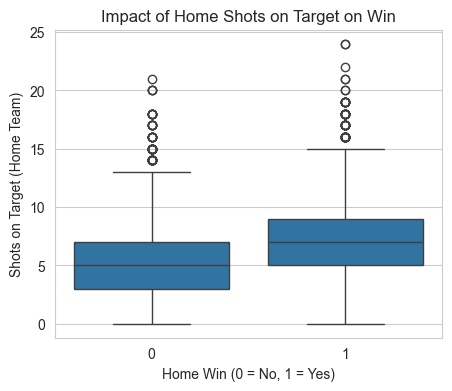

In [19]:
plt.figure(figsize=(5,4))
sns.boxplot(x='HomeWin', y='HomeShotsOnTarget', data=data)
plt.xlabel('Home Win (0 = No, 1 = Yes)')
plt.ylabel('Shots on Target (Home Team)')
plt.title('Impact of Home Shots on Target on Win')
plt.show()

In [20]:
correlation = data['HomeWin'].corr(data['HomeShotsOnTarget'])
print(f'Correlation: {correlation:.2f}')


Correlation: 0.31


The obtained correlation value is 0.31, which indicates a moderate positive relationship between the number of shots on target by the home team and the probability of winning. The visualization shows that teams that shoot on target more frequently generally have higher chances of winning. However, the presence of outliers suggests that a higher number of shots does not guarantee a victory.

**The Impact of the Number of Corners on the Match Outcome**

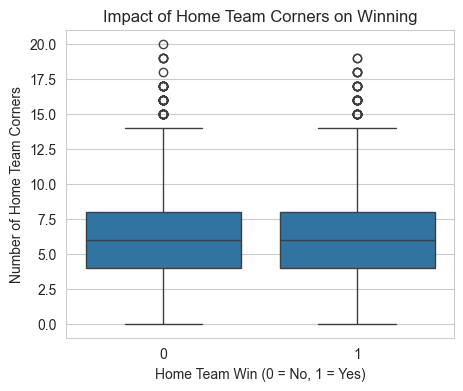

In [21]:
plt.figure(figsize=(5,4))

sns.boxplot(x='HomeWin', y='HomeCorners', data=data)

plt.xlabel('Home Team Win (0 = No, 1 = Yes)')
plt.ylabel('Number of Home Team Corners')
plt.title('Impact of Home Team Corners on Winning')

plt.show()


In [22]:
correlation_home_corners = data['HomeWin'].corr(data['HomeCorners'])
print(f'Correlation between the number of home team corners and a home win: {correlation_home_corners:.2f}')


Correlation between the number of home team corners and a home win: 0.04


The correlation between the number of home team corners and the match outcome is very weak (0.04). The boxplots show similar distributions of corners regardless of whether the home team won or lost.

This indicates that the number of corners is **not a significant** factor for predicting the match outcome in this dataset.

### Cumulative Team Goals Up to Each Match in the Season

To further enrich the data, we calculated the cumulative number of goals each team had scored in the current season up to just before each match.
This information reflects the team’s form and performance during the season and can serve as an additional input feature for a model predicting match outcomes.

The procedure is as follows:
- We iterate through the matches in the order they appear in the dataset.
- For each team (home and away), we keep track of the total goals scored so far in that season.
- These values are added as new columns to the table, representing the cumulative totals before the current match.
- The cumulative counts are reset at the start of each new season.

In [23]:
home_goals_cum = []
away_goals_cum = []

data_sorted = data.copy().reset_index(drop=True)

team_goals = {}

In [24]:

for idx, row in data_sorted.iterrows():
    season = row['Season']
    home_team = row['HomeTeamName']
    away_team = row['AwayTeamName']
    
    home_key = (season, home_team)
    away_key = (season, away_team)
    
    home_cum = team_goals.get(home_key, 0)
    away_cum = team_goals.get(away_key, 0)
    
    home_goals_cum.append(home_cum)
    away_goals_cum.append(away_cum)
    
    team_goals[home_key] = home_cum + row['FullTimeHomeGoals']
    team_goals[away_key] = away_cum + row['FullTimeAwayGoals']

In [25]:
data_sorted['HomeTeamGoalsFor'] = home_goals_cum
data_sorted['AwayTeamGoalsFor'] = away_goals_cum

data = data_sorted.copy()

### Overview of Cumulative Goal Difference and Its Impact on Match Outcome

A new column,`CumGoalDiff`, has been added to the dataset, representing the difference between the home and away teams’ cumulative goals prior to each match.

The following plot illustrates how this difference influences the match outcome, grouped by whether the home team won or not.

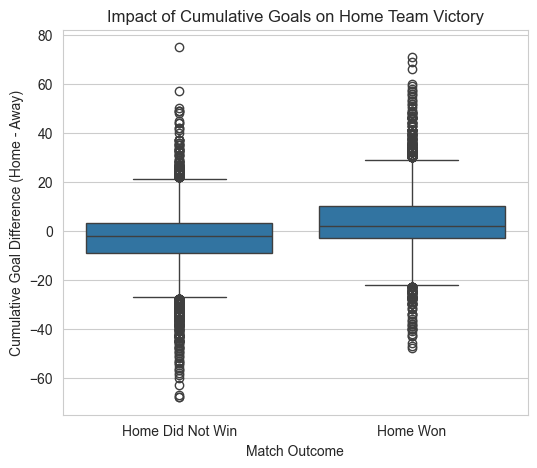

In [26]:
data['CumGoalDiff'] = data['HomeTeamGoalsFor'] - data['AwayTeamGoalsFor']

plt.figure(figsize=(6,5))
sns.boxplot(x='HomeWin', y='CumGoalDiff', data=data)

plt.xticks([0,1], ['Home Did Not Win', 'Home Won'])

plt.xlabel('Match Outcome')
plt.ylabel('Cumulative Goal Difference (Home - Away)')
plt.title('Impact of Cumulative Goals on Home Team Victory')

plt.show()


The boxplot shows that home teams that won tend to have a higher positive cumulative goal difference before the match, while home teams that did not win mostly have a difference close to zero or negative.

This suggests that a larger cumulative goal difference prior to a match correlates with a higher probability of a home team victory.


In [27]:
corr = data['CumGoalDiff'].corr(data['HomeWin'])
print(f"Correlation between cumulative goal difference and home team win: {corr:.3f}")


Correlation between cumulative goal difference and home team win: 0.282


The correlation is **0.282**, indicating a weak to moderate positive relationship.

- A higher cumulative goal difference in favor of the home team generally increases the chances of a home win.

- However, this relationship is not strong, meaning that there are other factors that significantly influence the match outcome.

- A correlation of 0.282 suggests that goal difference is neither the only nor the decisive factor for a victory.

### Calculating Cumulative Points by Season

Next, we calculate the cumulative points for each team in each season.
Points are awarded based on the match result:

- Home win = 3 points to the home team
- Draw = 1 point to both home and away teams
- Away win = 3 points to the away team

At the start of each season, cumulative points are reset to zero.


In [28]:
home_points_cum = []
away_points_cum = []

data_sorted = data.copy().reset_index(drop=True)

team_points = {}

In [29]:
for idx, row in data_sorted.iterrows():
    season = row['Season']
    home_team = row['HomeTeamName']
    away_team = row['AwayTeamName']
    
    home_key = (season, home_team)
    away_key = (season, away_team)
    
    home_cum = team_points.get(home_key, 0)
    away_cum = team_points.get(away_key, 0)
    
    home_points_cum.append(home_cum)
    away_points_cum.append(away_cum)
    
    if row['FullTimeResult'] == 1:  
        home_points = 3
        away_points = 0
    elif row['FullTimeResult'] == 0: 
        home_points = 1
        away_points = 1
    else: 
        home_points = 0
        away_points = 3

    
    team_points[home_key] = home_cum + home_points
    team_points[away_key] = away_cum + away_points

In [30]:
data_sorted['HomeTeamPoints'] = home_points_cum
data_sorted['AwayTeamPoints'] = away_points_cum

data = data_sorted.copy()

#### Analysis of the Impact of Home Team Cumulative Points on Match Outcome

This plot examines whether the total number of points the home team has accumulated up to the current match (cumulative) affects the probability of winning that match.

A boxplot is used to visualize the distribution of cumulative points for two groups:

- Matches in which the home team did not win
- Matches in which the home team won


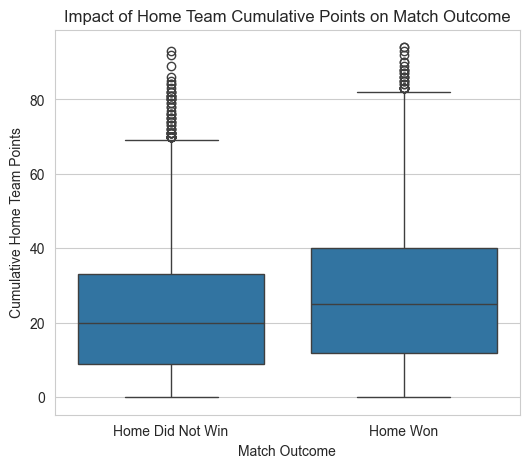

In [31]:
plt.figure(figsize=(6,5))

sns.boxplot(x='HomeWin', y='HomeTeamPoints', data=data)

plt.xticks([0,1], ['Home Did Not Win', 'Home Won'])

plt.xlabel('Match Outcome')
plt.ylabel('Cumulative Home Team Points')
plt.title('Impact of Home Team Cumulative Points on Match Outcome')

plt.show()



#### Key Observations:

- The median cumulative points are higher for home teams that won (around 25 points) compared to those that did not win (around 20 points).
- The range of values is quite wide in both groups, but for home wins, the upper quartile reaches higher values.
- Both groups contain noticeable outliers (matches where the home team has significantly more points than average).
- Although there is some overlap, the distribution indicates that teams with higher cumulative points tend to win more often.

#### Conclusion:

There is a positive trend showing that home teams with a higher cumulative number of points have a greater probability of winning, although the differences are not extremely pronounced and there is considerable overlap between the groups.

In [32]:
corr = data['HomeTeamPoints'].corr(data['HomeWin'])
print(f"Correlation between home team cumulative points and home win: {corr:.3f}")



Correlation between home team cumulative points and home win: 0.147


The correlation is **0.147**, indicating **a weak positive relationship** between the home team’s cumulative points and a home win.


### Calculating Team Form Over the Last 5 Matches

In this part of the code, we calculate the form of each team, separately for home and away teams, based on the results of their previous 5 matches.
Form is defined as the number of wins a team achieved in its last 5 matches (regardless of whether they played at home or away).

The resulting data is added to the DataFrame in the columns `HomeTeamForm` and `AwayTeamForm`.


##### Sorting and Creating a Column for Away Team Wins

First, we sort the data by the match date and add a new column indicating an away team win (AwayWin).
A value of `1` means the away team won, and `0` means the away team did not win.

In [33]:
data = data.sort_values('MatchDate')

data['HomeWin'] = (data['FullTimeResult'] == 1).astype(int)
data['Draw'] = (data['FullTimeResult'] == 0).astype(int)
data['AwayWin'] = (data['FullTimeResult'] == 2).astype(int)


##### Converting to Long Format and Calculating Form

The data is transformed into **long format**, where each row represents a single team in a single match, regardless of whether they were playing at home or away.

Next, a pivot table is created with teams as columns, and a **rolling sum** is calculated to determine the number of wins in the last 5 matches for each team.


In [34]:
home = data[['MatchDate', 'HomeTeamName', 'HomeWin']].rename(columns={'HomeTeamName': 'Team', 'HomeWin': 'Win'})
away = data[['MatchDate', 'AwayTeamName', 'AwayWin']].rename(columns={'AwayTeamName': 'Team', 'AwayWin': 'Win'})
all_results = pd.concat([home, away])

pivot = all_results.pivot_table(index='MatchDate', columns='Team', values='Win', aggfunc='sum').fillna(0)

rolling_form = pivot.rolling(window=5, min_periods=1).sum()


##### Adding Home and Away Team Form to the Main DataFrame

For each match, we retrieve the number of wins a team achieved in its last 5 matches (form) and add these values to the original DataFrame for the home team (`HomeTeamForm`) and the away team (`AwayTeamForm`).

In [35]:
def get_team_form(row, team):
    date = row['MatchDate']
    if team in rolling_form.columns and date in rolling_form.index:
        return rolling_form.at[date, team]
    else:
        return 0

data['HomeTeamForm'] = data.apply(lambda row: get_team_form(row, row['HomeTeamName']), axis=1)
data['AwayTeamForm'] = data.apply(lambda row: get_team_form(row, row['AwayTeamName']), axis=1)

data['HomeTeamForm'] = data['HomeTeamForm'].astype(int)
data['AwayTeamForm'] = data['AwayTeamForm'].astype(int)

### Correlation of Numerical Variables with HomeWin

We display the Pearson correlations of all numerical columns with the match outcome (`HomeWin`).
The results are sorted by absolute value to highlight the most important variables.

In [36]:
import numpy as np
import pandas as pd

num_cols = data.select_dtypes(include=[np.number]).columns

corr_mat = data[num_cols].corr(method='pearson')

target_corr = (
    corr_mat['HomeWin']
    .drop(labels=['HomeWin'], errors='ignore')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Top 15 correlations with HomeWin:")
display(target_corr.head(15).to_frame('corr'))


Top 15 correlations with HomeWin:


,corr
HomeTeamForm,0.699586
FullTimeHomeGoals,0.639640
AwayWin,-0.595149
Draw,-0.526235
FullTimeAwayGoals,-0.505094
HalfTimeHomeGoals,0.440752
AwayTeamForm,-0.416788
HalfTimeAwayGoals,-0.332640
HomeShotsOnTarget,0.310852
CumGoalDiff,0.281620


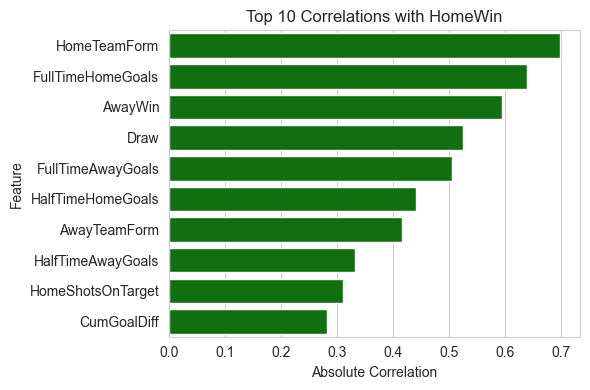

In [37]:
top_corr = target_corr.head(10)
plt.figure(figsize=(6,4))

sns.barplot(x=top_corr.abs(), y=top_corr.index, color="green")

plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.title("Top 10 Correlations with HomeWin")

plt.tight_layout()
plt.show()





The plot shows the top 10 numerical variables by absolute correlation with HomeWin.

- Strongest positive correlations:
  - `HomeTeamForm` (≈0.69) – home teams in better form win more often.
  - `FullTimeHomeGoals` (≈0.64) – the more goals the home team scores, the higher the chance of winning.
- Strongest negative correlations:
  - `AwayWin` (≈-0.59) – if the home team does not win, it is likely that the away team wins.
  - `AwayTeamForm` (≈-0.41) – a stronger away team reduces the home team’s chances of winning.
  - `FullTimeAwayGoals` (≈-0.50) – the more goals the away team scores, the lower the home team’s chances.
  - `Draw` (≈-0.52) – a draw decreases the probability of a home win.

Other variables show weaker, yet still relevant, relationships with HomeWin.

### Distribution of Cumulative Goal Difference (`CumGoalDiff`)

We display the distribution of cumulative goal difference prior to each match.
Colors indicate the match outcome (`HomeWin`): green = home team did not win, orange = home team won.

This plot helps visually assess how a goal advantage influences the probability of a home team victory.

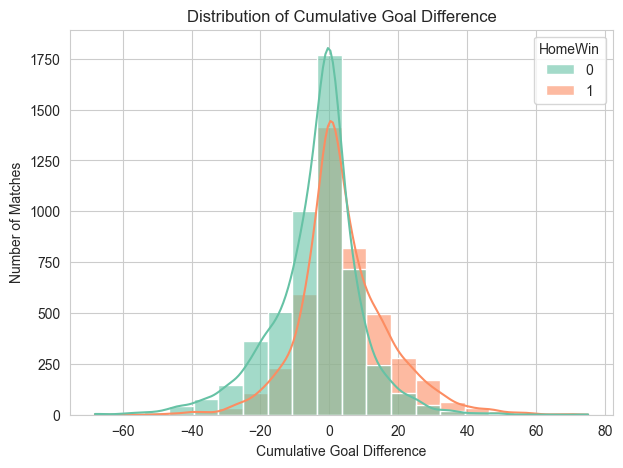

In [38]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=data,
    x='CumGoalDiff',
    hue='HomeWin',
    kde=True,
    bins=20,
    palette="Set2",
    alpha=0.6
)

plt.xlabel("Cumulative Goal Difference")
plt.ylabel("Number of Matches")
plt.title("Distribution of Cumulative Goal Difference")

plt.show()



##### Conclusion

The plot clearly shows that a higher cumulative advantage for the home team prior to a match increases the chances of a home win.
Although the distributions overlap and cumulative goal difference is not the only factor affecting the outcome, `CumGoalDiff` proves to be a valuable predictive variable and can be used in models for predicting match results.

### Impact of Home Team Form on the Probability of Winning

We analyze how the home team’s form (`HomeTeamForm`) affects the probability of a win.
Form is represented as the number of consecutive wins in previous matches prior to the one being considered.


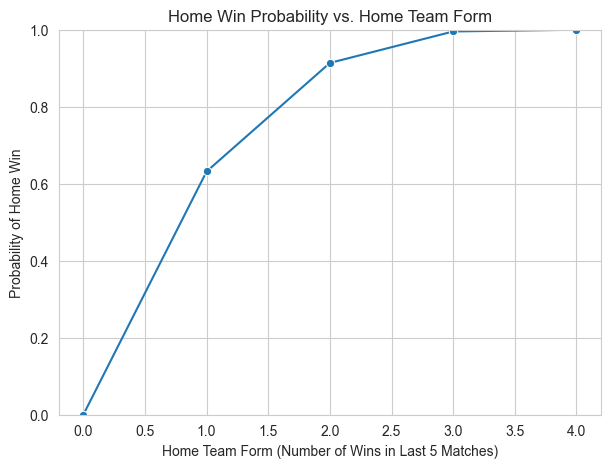

In [39]:
form_win_rate = data.groupby('HomeTeamForm')['HomeWin'].mean().reset_index()

plt.figure(figsize=(7,5))

sns.lineplot(data=form_win_rate, x='HomeTeamForm', y='HomeWin', marker='o')

plt.xlabel("Home Team Form (Number of Wins in Last 5 Matches)")
plt.ylabel("Probability of Home Win")
plt.title("Home Win Probability vs. Home Team Form")
plt.ylim(0,1)

plt.show()



**Observations:**

- There is a clear increase in the probability of a home win as the home team’s form improves.
- When the home team has poor form (0–1 consecutive wins), the chance of winning is significantly lower.
- With excellent form (4–5 consecutive wins), the probability of winning approaches its maximum.

**Conclusion:**
- Home team form is a strong predictor of match outcome and should be included as a feature in a machine learning model.


#### Analysis in Relation to FullTimeResult

So far, the analysis has focused on the `HomeWin` variable, where the match outcome was observed only from the perspective of a home win (binary: win or not win).

However, the goal is to predict the final match outcome, so we now use the `FullTimeResult` variable, which has three possible values:

- **0** → Draw

- **1** → Home Win

- **2** → Away Win

The first step is to examine how the number of home team goals affects the final match outcome.

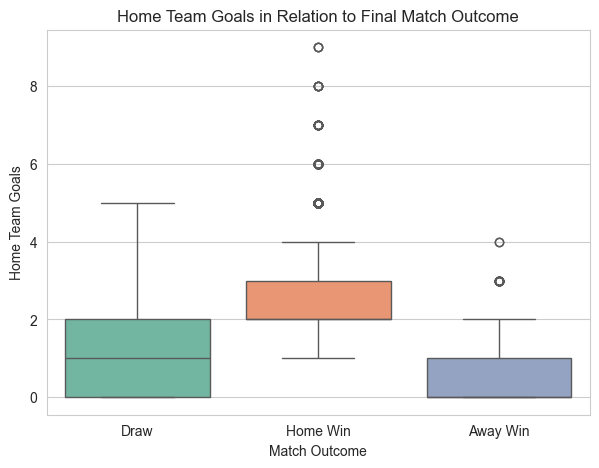

In [40]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='FullTimeResult',
    y='FullTimeHomeGoals',
    data=data,
    hue='FullTimeResult',
    palette='Set2',
    legend=False
)

plt.xticks([0,1,2], ['Draw', 'Home Win', 'Away Win'])
plt.xlabel("Match Outcome")
plt.ylabel("Home Team Goals")
plt.title("Home Team Goals in Relation to Final Match Outcome")

plt.show()


- In home wins, the median number of goals scored is the **highest** (around 2 goals), with the range reaching up to 8 goals in rare cases.
- In draws, home teams score on average around **1 goal**.
- In away wins, home teams score the fewest goals, usually **0 or 1**.

**Conclusion:**

The number of goals scored by the home team has a direct relationship with the final match outcome.
- A higher number of home goals significantly increases the probability of a home win.
- A low number of goals (0–1) most often leads to a draw or a loss.

##### Impact of Away Team Points on Win, Loss, or Draw

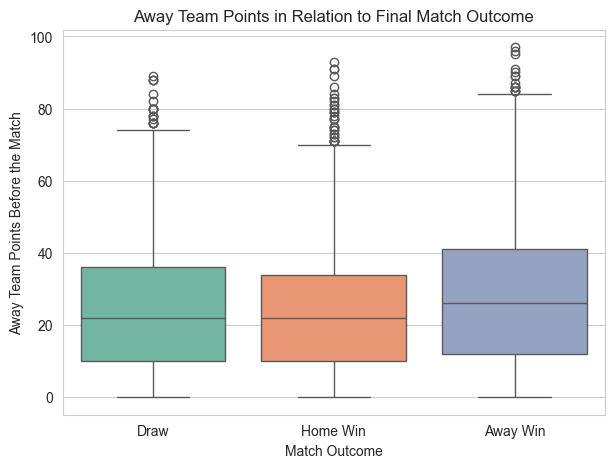

In [41]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='FullTimeResult',
    y='AwayTeamPoints',
    data=data,
    hue='FullTimeResult',
    palette='Set2',
    legend=False
)

plt.xticks([0,1,2], ['Draw', 'Home Win', 'Away Win'])
plt.xlabel("Match Outcome")
plt.ylabel("Away Team Points Before the Match")
plt.title("Away Team Points in Relation to Final Match Outcome")

plt.show()



**Conclusion**

- **Draw**: The median number of points is slightly above 20, indicating that teams with an average number of points often end up drawing matches.
- **Home Win**: The distribution is similar to that of draws, suggesting that even teams with a relatively high number of points can still lose or draw.
- **Away Win**: The median is around 25, and the upper quartile is higher than in the other groups, indicating some relationship between the number of points and an away win, although there is considerable variability.



##### Analysis of the Impact of Home Team Form on the Final Match Outcome

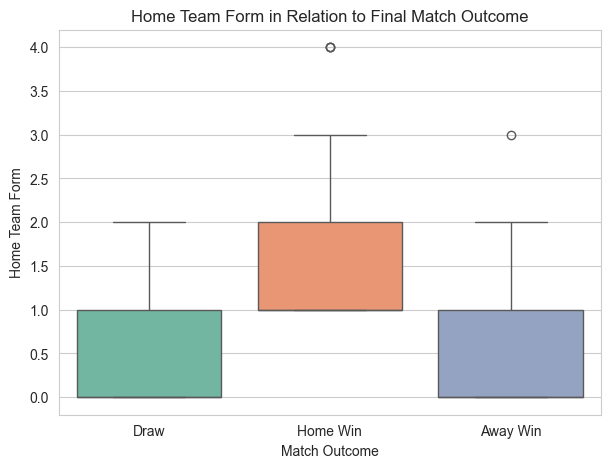

In [42]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='FullTimeResult',
    y='HomeTeamForm',
    data=data,
    hue='FullTimeResult',
    palette='Set2',
    legend=False
)

plt.xticks([0,1,2], ['Draw', 'Home Win', 'Away Win'])
plt.xlabel("Match Outcome")
plt.ylabel("Home Team Form")
plt.title("Home Team Form in Relation to Final Match Outcome")

plt.show()


- Better home team form generally leads to a home win.
- Poorer home team form is associated with draws or away wins.
- Outliers indicate that form is not the only factor, and match outcomes are influenced by other variables as well.

## Logistic Regression for Predicting Match Outcomes

In this section, we use multinomial logistic regression to predict match outcomes (**FullTimeResult**) based on previous statistical variables.

**Objective**
- Predict the match outcome: draw (0), home win (1), away win (2).
- Assess how well numerical variables (team form, previous goals, shots, etc.) influence the probability of each outcome.

**Approach**
- We will use a time-aware data split:
   - The model is trained on previous seasons and tested on the following season.
   - This approach simulates a real-world scenario of predicting future matches.
- Numerical variables are scaled using `StandardScaler`.
- Model evaluation will be presented through a **classification report** and a **confusion matrix**.

**Expectations**
- We expect moderate accuracy, as football results are inherently unpredictable.
- The model serves as a baseline, which can later be compared with more complex models such as Random Forest.


##### Libraries for Logistic Regression and Data Preparation

To train multinomial logistic regression, split the data, and evaluate the model, we use the following **scikit-learn** libraries:
- `train_test_split` – for splitting the data into training and test sets
- `StandardScaler` – for scaling numerical variables
- `LogisticRegression` – for training multinomial logistic regression
- `classification_report` and `confusion_matrix` – for evaluating model performance

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


##### Defining Input (X) and Target (y) Variables

In this step:

1. Define **X** – the input features selected based on their correlation with match outcomes.
2. Define **y** – the target variable `FullTimeResult` (0 = draw, 1 = home win, 2 = away win).
3. Scale all numerical input features using `StandardScaler` to improve the performance of the logistic regression model.

In [44]:
features = [
    'AwayTeamForm',
    'HomeTeamForm',
    'HomeShotsOnTarget',
    'CumGoalDiff',
    'AwayShotsOnTarget',
    'AwayShots',
    'HomeShots',
    'HomeTeamPoints',
    'AwayTeamPoints',
    'HomeTeamGoalsFor',
    'AwayTeamGoalsFor'
]

X = data[features]  
Y = data['FullTimeResult']  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


##### Time-Based Data Split by Seasons (Expanding Window)

We use an **expanding window** approach that respects the chronological order of the data:

- The training set consists of **all previous seasons** up to the season being tested.  
- The test set is always **only the next season** that the model has not seen before.  
- This way, the training set **gradually expands**, while the test set remains fixed to a single season.  

**Example:**  
- To test the 2003 season, train on 2000–2002 seasons.  
- To test the 2004 season, train on 2000–2003 seasons.  
- To test the 2005 season, train on 2000–2004 seasons, and so on.  

This approach simulates **real-world prediction of future matches**, as the model does not use data from future seasons.  
The column `SeasonStart` indicates the season start year and ensures correct chronological sorting of the data.



In [45]:
seasons = sorted(data['SeasonStart'].unique())

expanding_splits = []

for i in range(1, len(seasons)):
    train_seasons = seasons[:i]       
    test_season = seasons[i]         
    
    X_train = X_scaled[data['SeasonStart'].isin(train_seasons)]
    Y_train = Y[data['SeasonStart'].isin(train_seasons)]
    
    X_test = X_scaled[data['SeasonStart'] == test_season]
    Y_test = Y[data['SeasonStart'] == test_season]
    
    expanding_splits.append({
        'train_seasons': train_seasons,
        'test_season': test_season,
        'X_train': X_train,
        'Y_train': Y_train,
        'X_test': X_test,
        'Y_test': Y_test
    })


##### Training the Model and Saving Predictions

In this block, we iterate through all prepared **train/test splits** and do the following:

1. For each iteration, take the **train set** (`X_train`, `Y_train`) and **test set** (`X_test`, `Y_test`).  
2. The model makes predictions on the test set (`Y_pred`).  
3. For each test season, we save:
   - `test_season` → the season being tested  
   - `Y_test` → actual outcomes  
   - `Y_pred` → model predictions  
4. All of this is stored in the list `all_preds` for later evaluation.  

This approach allows us to process **one season at a time** while keeping all predictions for later analysis.

In [46]:
all_preds_expanding = []

for split in expanding_splits:
    X_train = split['X_train']
    Y_train = split['Y_train']
    X_test = split['X_test']
    Y_test = split['Y_test']
    
    model = LogisticRegression(solver='lbfgs', max_iter=1000)
    model.fit(X_train, Y_train)
    
    Y_pred = model.predict(X_test)
    
    all_preds_expanding.append({
        'test_season': split['test_season'],
        'Y_test': Y_test,
        'Y_pred': Y_pred
    })


##### Model Evaluation by Season

For each season, we display the classification results to see how well the model predicts match outcomes:

- `classification_report` shows **precision**, **recall**, and **F1-score** for each class (draw = 0, home win = 1, away win = 2).  
- `confusion_matrix` provides a detailed view of correct and incorrect predictions by class.  
- This allows us to analyze performance **season by season** and observe if the model performs better or worse in certain seasons.

In [47]:
for pred in all_preds_expanding:
    print(f"Season: {pred['test_season']}")
    print(classification_report(pred['Y_test'], pred['Y_pred']))
    print(confusion_matrix(pred['Y_test'], pred['Y_pred']))

Season: 2001
              precision    recall  f1-score   support

           0       0.75      0.59      0.66       101
           1       0.80      0.99      0.88       165
           2       0.85      0.71      0.78       114

    accuracy                           0.80       380
   macro avg       0.80      0.76      0.77       380
weighted avg       0.80      0.80      0.79       380

[[ 60  29  12]
 [  0 163   2]
 [ 20  13  81]]
Season: 2002
              precision    recall  f1-score   support

           0       0.73      0.40      0.52        90
           1       0.80      0.94      0.87       187
           2       0.71      0.77      0.73       103

    accuracy                           0.77       380
   macro avg       0.75      0.70      0.71       380
weighted avg       0.76      0.77      0.75       380

[[ 36  30  24]
 [  2 176   9]
 [ 11  13  79]]
Season: 2003
              precision    recall  f1-score   support

           0       0.72      0.45      0.56        9

##### Analysis of Results by Season

- **Home wins (class 1)** are consistently predicted the best – precision and recall are generally high, often above 85–90%.  

- **Draws (class 0)** and **away wins (class 2)** are more challenging for the model: precision and recall vary between 40% and 85%, depending on the season.  

- The model shows a clear bias toward the home team, while less frequent outcomes like draws and away wins are harder to predict.  

- Overall accuracy per season ranges roughly between 74% and 87%, with some seasonal fluctuations.  

- Confusion matrices indicate that draws are often misclassified as home or away wins, whereas home wins are recognized consistently.  

- This trend remains stable across all seasons: the model reliably predicts the more frequent outcomes (home wins), while rarer outcomes (draws and away wins) remain challenging, which is also reflected in the F1-score analysis.



##### Overall Results (All Seasons Combined)

So far, results have been shown **by season**, but to get a **complete picture of model performance**, we need to combine all test sets and their predictions.  
This allows us to calculate **overall accuracy, precision, recall, and F1-score** for the model across all seasons.



In [48]:
all_y_test = np.concatenate([res['Y_test'] for res in all_preds_expanding])
all_y_pred = np.concatenate([res['Y_pred'] for res in all_preds_expanding])

print("Overall Results Across All Seasons")
print(classification_report(all_y_test, all_y_pred, digits=2))
print(confusion_matrix(all_y_test, all_y_pred))

Overall Results Across All Seasons
              precision    recall  f1-score   support

           0       0.77      0.50      0.61      2212
           1       0.81      0.96      0.88      4115
           2       0.79      0.79      0.79      2673

    accuracy                           0.80      9000
   macro avg       0.79      0.75      0.76      9000
weighted avg       0.79      0.80      0.78      9000

[[1107  675  430]
 [  34 3957  124]
 [ 295  275 2103]]


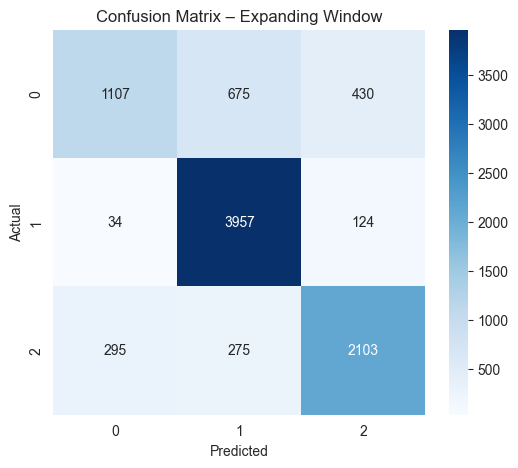

In [50]:
cm = confusion_matrix(all_y_test, all_y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0,1,2],
    yticklabels=[0,1,2]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Expanding Window")
plt.show()

##### Interpretation of Overall Results

- The model achieves an **overall accuracy of 80%** across all seasons.  
- It predicts **home wins (class 1)** most reliably, with **precision 0.81** and **recall 0.96**.  
- **Draws (class 0)** and **away wins (class 2)** are more challenging for the model, with F1-scores around **0.61–0.79**.  
- The confusion matrix shows that the model most often confuses draws and away wins, while home wins are recognized consistently.  

**Conclusion:** The model is most reliable in predicting home wins, while draws and away wins remain more difficult to predict.


##### Time-Based Data Split by Seasons (Rolling Window)

In this step, we prepare the data for training and testing the model using a **rolling window approach**:

- The training set consists of a **fixed number of consecutive seasons** (e.g., 3 seasons).  
- The test set is the **next season** that the model has not seen before.  
- After each iteration, the **window moves forward** by one season, while the size of the training set remains fixed



In [51]:
train_window = 3
seasons = sorted(data['SeasonStart'].unique())

rolling_splits = []

for i in range(len(seasons) - train_window):
    train_seasons = seasons[i:i+train_window]
    test_season = seasons[i+train_window]
    
    X_train = X_scaled[data['SeasonStart'].isin(train_seasons)]
    Y_train = Y[data['SeasonStart'].isin(train_seasons)]
    
    X_test = X_scaled[data['SeasonStart'] == test_season]
    Y_test = Y[data['SeasonStart'] == test_season]
    
    rolling_splits.append({
        'train_seasons': train_seasons,
        'test_season': test_season,
        'X_train': X_train,
        'Y_train': Y_train,
        'X_test': X_test,
        'Y_test': Y_test
    })


##### Training and Prediction Using Rolling Window

In this step, we train **multinomial logistic regression** for each split defined by the rolling window approach:

- For each window across seasons, we extract the training and test sets.  
- Train the model on the training data.  
- Predict the outcomes for the next season and save the results for later analysis.  
- Predictions are stored in the list `all_preds_rolling` for evaluating model performance across all seasons.


In [52]:
all_preds_rolling = []

for split in rolling_splits:
    X_train = split['X_train']
    Y_train = split['Y_train']
    X_test = split['X_test']
    Y_test = split['Y_test']
    
    model = LogisticRegression(solver='lbfgs', max_iter=1000)
    model.fit(X_train, Y_train)
    
    Y_pred = model.predict(X_test)
    
    all_preds_rolling.append({
        'test_season': split['test_season'],
        'Y_test': Y_test,
        'Y_pred': Y_pred
    })


##### Model Evaluation by Season (Rolling Window)

In [54]:
for pred in all_preds_rolling:
    print(f"Season: {pred['test_season']}")
    print(classification_report(pred['Y_test'], pred['Y_pred'], digits=2))
    print(confusion_matrix(pred['Y_test'], pred['Y_pred']))


Season: 2003
              precision    recall  f1-score   support

           0       0.72      0.45      0.56        93
           1       0.78      0.92      0.84       150
           2       0.72      0.77      0.74        92

    accuracy                           0.75       335
   macro avg       0.74      0.71      0.71       335
weighted avg       0.75      0.75      0.74       335

[[ 42  32  19]
 [  3 138   9]
 [ 13   8  71]]
Season: 2004
              precision    recall  f1-score   support

           0       0.78      0.45      0.57        96
           1       0.76      0.93      0.84       150
           2       0.75      0.80      0.77        89

    accuracy                           0.76       335
   macro avg       0.76      0.73      0.73       335
weighted avg       0.76      0.76      0.74       335

[[ 43  36  17]
 [  3 140   7]
 [  9   9  71]]
Season: 2005
              precision    recall  f1-score   support

           0       0.59      0.53      0.56        7

##### Analysis by Season for Rolling Window Approach

- **Overall accuracy per season** ranges around **74–86%**, showing relatively stable model performance across years.  
- The model predicts **home wins (class 1)** most reliably, with high precision and recall, often above **0.80 / 0.95**.  
- **Draws (class 0)** and **away wins (class 2)** are more difficult to predict, with F1-scores generally between **0.53–0.74**, depending on the season.  
- The confusion matrix shows:
  - Draws are often misclassified as home or away wins.  
  - Home wins are consistently recognized.  
  - Predictions for away wins vary more, especially in seasons with high result fluctuations (e.g., 2005, 2013).  
- This approach realistically simulates predicting the **next season** without looking at future data, but indicates that the model is **sensitive to rarer outcomes** and seasonal variations.


In [55]:
all_y_test = np.concatenate([res['Y_test'] for res in all_preds_rolling])
all_y_pred = np.concatenate([res['Y_pred'] for res in all_preds_rolling])

print("Overall Results Across All Seasons:")
print(classification_report(all_y_test, all_y_pred, digits=2))
print(confusion_matrix(all_y_test, all_y_pred))

Overall Results Across All Seasons:
              precision    recall  f1-score   support

           0       0.77      0.51      0.62      2021
           1       0.81      0.95      0.88      3763
           2       0.79      0.80      0.80      2456

    accuracy                           0.80      8240
   macro avg       0.79      0.76      0.76      8240
weighted avg       0.80      0.80      0.79      8240

[[1038  593  390]
 [  52 3591  120]
 [ 256  241 1959]]


##### Overall Results Across All Seasons (Rolling Window)

- The model achieves an **overall accuracy of 80%**, demonstrating solid ability to predict match outcomes.  
- It predicts **home wins (class 1)** most reliably, with high precision (**0.81**) and recall (**0.95**).  
- **Draws (class 0)** and **away wins (class 2)** are more challenging, with slightly lower F1-scores (**0.62–0.80**).  
- The confusion matrix shows that draws are often confused with away wins, while home wins are mostly recognized correctly.  
- These results confirm the trend that the model learns and predicts the more frequent outcomes (home wins) better, whereas rarer outcomes remain challenging.
  


##### Comparative Analysis of Rolling vs Expanding Window Approaches

- **Overall Accuracy:** Both approaches achieve **80%** accuracy.  

- **Home Wins (class 1):** identical (F1 0.88 vs 0.88).  
- **Draws (class 0):** Rolling slightly better (F1 0.62 vs 0.61).  
- **Away Wins (class 2):** Rolling also slightly better (F1 0.80 vs 0.79).  

- **Conclusion:** The Rolling Window approach slightly outperforms Expanding in predicting rarer outcomes, while both approaches are stable for home wins.


### Visualization of Model Accuracy by Season

The goal of this visualization is to:  

- Show how model performance varies over the years.  
- Compare the stability and sensitivity of both approaches to seasonal changes.  
- Identify periods when the model predicts match outcomes better or worse.  

The plot will allow easy tracking of overall accuracy trends and seasonal fluctuations for both approaches.


In [56]:
from sklearn.metrics import accuracy_score

accuracy_expanding = []
seasons_expanding = []

for item in all_preds_expanding:
    acc = accuracy_score(item['Y_test'], item['Y_pred'])
    accuracy_expanding.append(acc)
    seasons_expanding.append(item['test_season'])

accuracy_rolling = []
seasons_rolling = []

for item in all_preds_rolling:
    acc = accuracy_score(item['Y_test'], item['Y_pred'])
    accuracy_rolling.append(acc)
    seasons_rolling.append(item['test_season'])

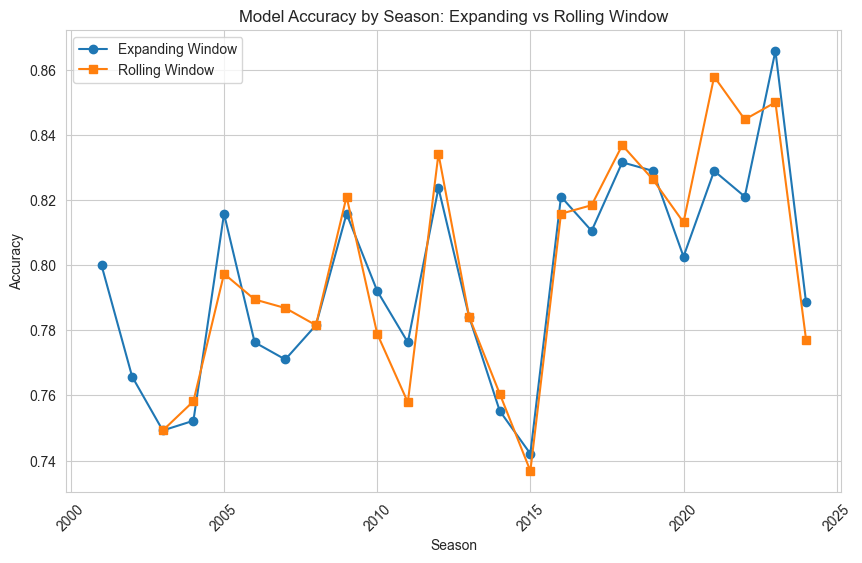

In [57]:
plt.figure(figsize=(10,6))
plt.plot(seasons_expanding, accuracy_expanding, marker='o', label='Expanding Window')
plt.plot(seasons_rolling, accuracy_rolling, marker='s', label='Rolling Window')
plt.xticks(rotation=45)
plt.xlabel("Season")
plt.ylabel("Accuracy")
plt.title("Model Accuracy by Season: Expanding vs Rolling Window")
plt.legend()
plt.grid(True)
plt.show()

##### Conclusion of Model Accuracy Visualization

The plot shows model accuracy by season using two training strategies: **Expanding Window** and **Rolling Window**.

**General Trends:**
- Both models follow a similar trend, with accuracy ranging from ~0.74 to 0.87.  
- Expanding Window is more stable, especially in earlier seasons.  
- Rolling Window sometimes fluctuates more, with dips in certain seasons (e.g., 2015).  

**Conclusion:**
- Expanding Window provides more stable predictions over a longer period.  
- Rolling Window may be better at capturing seasonal fluctuations and short-term trends.


### Conclusion for Logistic Regression  

By applying **logistic regression**, a first attempt was made to predict football match outcomes based on available statistical variables.  

In this part of the analysis:  
- Data were prepared and used to train the model with time-aware logic (**Expanding** and **Rolling Window**).  
- Model performance was analyzed both season by season and overall, comparing accuracy, precision, and F1-score.  
- It was found that the model predicts **home wins** most reliably, while draws and away wins are significantly harder to predict.  

**Key Insights:**  
- Results vary between seasons, reflecting the influence of factors not included in the data (e.g., player form, injuries, coach tactics, transfers, unexpected events).  
- Although logistic regression does not yield perfect results, it demonstrates a solid level of accuracy and provides a foundation for understanding patterns in the data.  
- Time-aware training approaches (Expanding and Rolling Window) proved useful as they better simulate real-world prediction of future matches.  

This model provides a good starting point, and the next step will be to apply more advanced machine learning methods, such as **Random Forest**, to explore whether more complex algorithms can offer improved solutions.



### Random Forest for Predicting Match Outcomes

After exploring the capabilities of **logistic regression**, the next step is applying the **Random Forest algorithm**.  

Unlike logistic regression, which relies on linear relationships between variables and the target class, Random Forest uses an ensemble of decision trees. Each tree makes its own prediction, and the final outcome is determined by majority voting.  

**Advantages of Random Forest over logistic regression:**
- Better captures **nonlinear relationships** between variables.  
- Less sensitive to noise and the lack of linear structure in the data.  
- Often achieves higher accuracy in predicting complex phenomena, such as football match outcomes.  

Next, we will train a Random Forest using the same data and evaluation metrics as in logistic regression, allowing us to **compare results between the two approaches**.


##### Import Required Libraries

For Random Forest, we use `RandomForestClassifier` from the `sklearn.ensemble` package.  
This class allows training a Random Forest model, which combines multiple decision trees to achieve better accuracy and prediction stability.


In [58]:
from sklearn.ensemble import RandomForestClassifier

##### Random Forest with Expanding Window Approach

In this section, we use the **Random Forest classifier** to predict match outcomes, applying the **Expanding Window** training method.  
This approach allows the model to learn from all previous seasons and test predictions on the next season, simulating real-world prediction of future matches.



In [59]:
all_preds_exp_rf = []

for split in expanding_splits:
    X_train = split['X_train']
    Y_train = split['Y_train']
    X_test = split['X_test']
    Y_test = split['Y_test']
    
    model_rf = RandomForestClassifier()
    model_rf.fit(X_train, Y_train)
    
    Y_pred = model_rf.predict(X_test)
    
    all_preds_exp_rf.append({
        'test_season': split['test_season'],
        'Y_test': Y_test,
        'Y_pred': Y_pred
    })


##### Model Evaluation by Season

For each season, we display classification results to assess how well the model predicts match outcomes.


In [63]:
for pred in all_preds_exp_rf:
    print(f"Season: {pred['test_season']}")
    print(classification_report(pred['Y_test'], pred['Y_pred']))
    print(confusion_matrix(pred['Y_test'], pred['Y_pred']))

Season: 2001
              precision    recall  f1-score   support

           0       0.67      0.60      0.64       101
           1       0.79      0.94      0.86       165
           2       0.85      0.68      0.76       114

    accuracy                           0.77       380
   macro avg       0.77      0.74      0.75       380
weighted avg       0.77      0.77      0.77       380

[[ 61  28  12]
 [  8 155   2]
 [ 22  14  78]]
Season: 2002
              precision    recall  f1-score   support

           0       0.70      0.41      0.52        90
           1       0.79      0.96      0.87       187
           2       0.74      0.71      0.73       103

    accuracy                           0.76       380
   macro avg       0.74      0.69      0.70       380
weighted avg       0.75      0.76      0.75       380

[[ 37  31  22]
 [  4 180   3]
 [ 12  18  73]]
Season: 2003
              precision    recall  f1-score   support

           0       0.74      0.45      0.56        9

##### Season-by-Season Analysis (Expanding Window)

- **Home wins (class 1)** are the most stable and accurately predicted across all seasons – precision and recall are generally above **85%**, often exceeding **90%**.  
- **Draws (class 0)** and **away wins (class 2)** show significantly weaker performance. Recall for these outcomes often does not exceed **50–60%**, with precision ranging between **40% and 70%**.  
- The model shows a clear **bias towards home wins**, as seen in confusion matrices where draws and away wins are frequently misclassified as home wins.  
- **Overall model accuracy** ranges between **65% and 77%**, with seasonal variations – highest values occur in the 2016–2019 and 2021 seasons, while lower performance is observed in early seasons and specific years such as 2003, 2011, and 2014.  
- **General trend:** the model remains reliable when predicting home wins, while draws and away wins are much more challenging, which aligns with the nature of football, where these outcomes are rarer and harder to predict.
  


##### Overall Results (All Seasons Combined)


In [64]:
all_y_test = np.concatenate([res['Y_test'] for res in all_preds_exp_rf])
all_y_pred = np.concatenate([res['Y_pred'] for res in all_preds_exp_rf])

print("Overall Results Across All Seasons:")
print(classification_report(all_y_test, all_y_pred, digits=2))
print(confusion_matrix(all_y_test, all_y_pred))

Overall Results Across All Seasons:
              precision    recall  f1-score   support

           0       0.76      0.48      0.59      2212
           1       0.80      0.95      0.87      4115
           2       0.78      0.80      0.79      2673

    accuracy                           0.79      9000
   macro avg       0.78      0.74      0.75      9000
weighted avg       0.79      0.79      0.78      9000

[[1071  681  460]
 [  75 3917  123]
 [ 270  276 2127]]


##### Overall Results of the Random Forest Model

- **Home wins (class 1):** Best predicted, precision 0.80, recall 0.95.  
- **Draws (class 0):** Weaker performance, precision 0.76, recall around 0.48.  
- **Away wins (class 2):** Moderate performance, precision 0.78, recall around 0.80.  
- **Overall accuracy:** 79%.  
- **Macro F1-score:** 0.75, indicating class imbalance.  
- **Conclusion:** The model predicts **home wins** very reliably, while **draws** and **away wins** remain more challenging.


##### Random Forest with Rolling Window Approach

In this section, we use the **Random Forest classifier** to predict match outcomes, applying the **Rolling Window** training method.


In [65]:
all_preds_roll_rf = []

for split in rolling_splits:
    X_train = split['X_train']
    Y_train = split['Y_train']
    X_test = split['X_test']
    Y_test = split['Y_test']
    
    model = RandomForestClassifier()
    model.fit(X_train, Y_train)
    
    Y_pred = model.predict(X_test)
    
    all_preds_roll_rf.append({
        'test_season': split['test_season'],
        'Y_test': Y_test,
        'Y_pred': Y_pred
    })


##### Model Evaluation by Season

In [67]:
for pred in all_preds_roll_rf:
    print(f"Season: {pred['test_season']}")
    print(classification_report(pred['Y_test'], pred['Y_pred']))
    print(confusion_matrix(pred['Y_test'], pred['Y_pred']))

Season: 2003
              precision    recall  f1-score   support

           0       0.78      0.43      0.56        93
           1       0.77      0.98      0.86       150
           2       0.76      0.77      0.76        92

    accuracy                           0.77       335
   macro avg       0.77      0.73      0.73       335
weighted avg       0.77      0.77      0.75       335

[[ 40  32  21]
 [  1 147   2]
 [ 10  11  71]]
Season: 2004
              precision    recall  f1-score   support

           0       0.85      0.47      0.60        96
           1       0.76      0.95      0.85       150
           2       0.75      0.81      0.78        89

    accuracy                           0.77       335
   macro avg       0.79      0.74      0.74       335
weighted avg       0.78      0.77      0.76       335

[[ 45  34  17]
 [  1 142   7]
 [  7  10  72]]
Season: 2005
              precision    recall  f1-score   support

           0       0.70      0.55      0.61        7

#### Season-by-Season Analysis (Rolling Window)

- **Home wins (class 1)** are the most reliably predicted, with precision and recall generally **85–92%**.  
- **Draws (class 0)** and **away wins (class 2)** are less accurately predicted, F1-score **40–60%**.  
- Model accuracy varies across seasons between **65% and 77%**.  
- The model shows **higher reliability for home wins** compared to draws and away wins.


##### Overall Results (All Seasons Combined)


In [69]:
all_y_test = np.concatenate([res['Y_test'] for res in all_preds_roll_rf])
all_y_pred = np.concatenate([res['Y_pred'] for res in all_preds_roll_rf])

print("Overall Results Across All Seasons :")
print(classification_report(all_y_test, all_y_pred, digits=2))
print(confusion_matrix(all_y_test, all_y_pred))

Overall Results Across All Seasons :
              precision    recall  f1-score   support

           0       0.77      0.48      0.59      2021
           1       0.80      0.95      0.87      3763
           2       0.78      0.80      0.79      2456

    accuracy                           0.79      8240
   macro avg       0.78      0.74      0.75      8240
weighted avg       0.79      0.79      0.78      8240

[[ 961  624  436]
 [  62 3584  117]
 [ 224  266 1966]]


##### Overall Results of the Random Forest Model with Rolling Window

- **Home wins (class 1):** Best predicted, precision 0.80, recall 0.95.  
- **Draws (class 0):** Weaker performance, precision 0.77, recall 0.48.  
- **Away wins (class 2):** Moderate performance, precision 0.78, recall 0.80.  
- **Overall accuracy:** 79%.  
- **Macro F1-score:** 0.75, indicating class imbalance.



##### Comparison Between Logistic Regression and Random Forest

- **Overall accuracy:** Logistic Regression slightly outperforms Random Forest (≈80% vs ≈79%).  
- **Home win prediction (class 1):** Both models predict home wins well, with Logistic Regression having a slight edge.  
- **Draw prediction (class 0):** Random Forest performs weaker (precision and recall ≈0.50), while Logistic Regression achieves better values.  
- **Away win prediction (class 2):** Logistic Regression predicts slightly better (F1-score ≈0.64–0.65) than Random Forest (≈0.61).  
- **Seasonal stability:** Logistic Regression provides more consistent results; Random Forest varies more, especially for draws and away wins.  

**Conclusion:**  
Although Random Forest is a more complex model, Logistic Regression is more stable and achieves equal or better performance, indicating that simple linear models can be efficient for this type of data.



### Final Conclusion

This study explored different approaches for predicting football match outcomes using statistical data:  

- The data were prepared and processed to enable model training with temporal logic (Expanding and Rolling Window).  
- **Logistic Regression** and **Random Forest** were applied, and their performance was analyzed both by season and overall.  
- Both models best predict **home wins**, while **draws** and **away wins** are more challenging to classify accurately.  
- The more complex model (Random Forest) did not yield significantly better results than the simpler Logistic Regression, showing that linear models can be effective for this type of data.  

This work provides a foundation for understanding patterns in football matches and serves as a solid starting point for further research.
